In [1]:

import os
import random
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)


2026-05-04 23:56:29.583880: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777938989.820116      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777938989.888364      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777938990.417099      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777938990.417145      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777938990.417148      57 computation_placer.cc:177] computation placer alr

In [2]:


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (100, 100)
BATCH_SIZE = 32
MAX_CLASSES = 20         
EPOCHS_BASELINE = 6
EPOCHS_CUSTOM_CNN = 8
EPOCHS_MOBILENET = 8
VALIDATION_SPLIT = 0.20

IS_KAGGLE = Path('/kaggle').exists()
WORK_DIR = Path('/kaggle/working') if IS_KAGGLE else Path.cwd() / 'working_outputs'
PLOT_DIR = WORK_DIR / 'plots'
MODEL_DIR = WORK_DIR / 'models'
REPORT_DIR = WORK_DIR / 'reports'

for d in [WORK_DIR, PLOT_DIR, MODEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('=' * 70)
print('TensorFlow version:', tf.__version__)
print('Running on Kaggle:', IS_KAGGLE)
print('Working directory:', WORK_DIR)
print('=' * 70)


try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    print('GPU detected:', len(gpus))
except Exception as e:
    print('GPU setup skipped:', repr(e))

TensorFlow version: 2.19.0
Running on Kaggle: True
Working directory: /kaggle/working
GPU detected: 2


In [3]:


def count_image_files(folder: Path) -> int:
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
    if not folder.exists():
        return 0
    return sum(1 for p in folder.rglob('*') if p.suffix.lower() in exts)


def find_fruits360_root() -> Path:
    """Locate the root directory that contains the Training and Test folders of the Fruits-360 dataset.
Supports multiple directory structures of the moltean/fruits dataset on Kaggle.
    """
    search_bases = []
    if IS_KAGGLE:
        search_bases.append(Path('/kaggle/input'))
    search_bases += [Path.cwd(), Path.cwd() / 'data', Path('/mnt/data')]

    candidates = []
    for base in search_bases:
        if not base.exists():
            continue
        for train_dir in base.rglob('Training'):
            test_dir = train_dir.parent / 'Test'
            if test_dir.exists():
                n_train = count_image_files(train_dir)
                n_test = count_image_files(test_dir)
                if n_train > 0 and n_test > 0:
                    candidates.append((train_dir.parent, n_train, n_test))

    if not candidates:
        raise FileNotFoundError('''
            "Fruits-360 dataset not found. On Kaggle, go to Add Data and add the "moltean/fruits" dataset."
            "The dataset must contain two folders: Training and Test."'''     )

    candidates = sorted(
        candidates,
        key=lambda x: (('fruit' not in str(x[0]).lower()), -(x[1] + x[2]), len(str(x[0]))),
    )
    return candidates[0][0]


DATA_ROOT = find_fruits360_root()
TRAIN_DIR = DATA_ROOT / 'Training'
TEST_DIR = DATA_ROOT / 'Test'

print('Dataset root:', DATA_ROOT)
print('Training images:', count_image_files(TRAIN_DIR))
print('Test images:', count_image_files(TEST_DIR))

Dataset root: /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360
Training images: 135071
Test images: 45008


Original number of classes: 257
Selected number of classes: 20
Selected classes: ['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20', 'Apple 21', 'Apple 22', 'Apple 23', 'Apple 5', 'Apple 6', 'Apple 7', 'Apple 8', 'Apple 9', 'Apple Braeburn 1', 'Apple Crimson Snow 1']


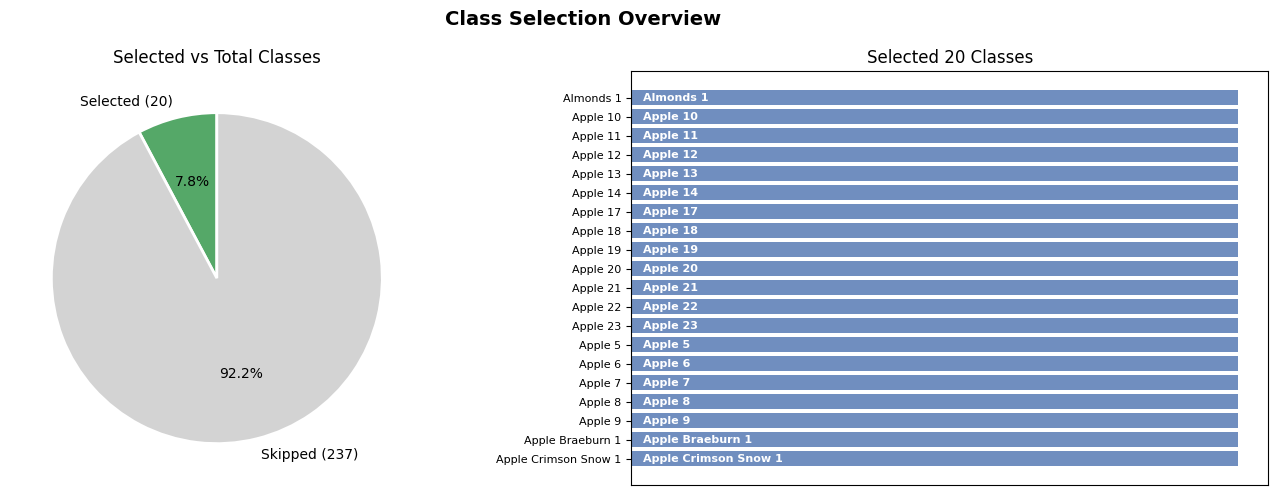

In [4]:
# =========================================================
# 3. SELECT 10-20 CLASSES FOR STABLE TRAINING
# =========================================================
all_classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
if not all_classes:
    raise ValueError('No classes found in the Training directory.')

selected_classes = all_classes[:min(MAX_CLASSES, len(all_classes))]
NUM_CLASSES = len(selected_classes)

if NUM_CLASSES < 2:
    raise ValueError('At least 2 classes are required to train a classification model.')

print('Original number of classes:', len(all_classes))
print('Selected number of classes:', NUM_CLASSES)
print('Selected classes:', selected_classes)

# Save the class list for use in reports and demos.
with open(WORK_DIR / 'selected_classes.json', 'w', encoding='utf-8') as f:
    json.dump(selected_classes, f, ensure_ascii=False, indent=2)

# ── Visualization: selected vs total classes ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Selection Overview', fontsize=14, fontweight='bold')

# Left: pie chart — selected vs skipped
ax1 = axes[0]
skipped = len(all_classes) - NUM_CLASSES
ax1.pie(
    [NUM_CLASSES, skipped],
    labels=[f'Selected ({NUM_CLASSES})', f'Skipped ({skipped})'],
    colors=['#55A868', '#D3D3D3'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax1.set_title('Selected vs Total Classes')

# Right: horizontal bar — one bar per selected class (placeholder count = 1 each)
ax2 = axes[1]
y_pos = range(NUM_CLASSES)
ax2.barh(list(y_pos), [1] * NUM_CLASSES, color='#4C72B0', alpha=0.8)
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(selected_classes, fontsize=8)
ax2.set_xticks([])
ax2.set_title(f'Selected {NUM_CLASSES} Classes')
ax2.invert_yaxis()
for i, name in enumerate(selected_classes):
    ax2.text(0.02, i, name, va='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'selected_classes.png', dpi=200, bbox_inches='tight')
plt.show()


EDA - class distribution:
                   class  n_images_train  n_images_test  total  train_ratio
0              Almonds 1             232             77    309     0.750809
1               Apple 10             699            231    930     0.751613
2               Apple 11             430            142    572     0.751748
3               Apple 12             466            154    620     0.751613
4               Apple 13             699            235    934     0.748394
5               Apple 14             466            154    620     0.751613
6               Apple 17             610            201    811     0.752158
7               Apple 18             724            240    964     0.751037
8               Apple 19             729            241    970     0.751546
9               Apple 20             702            234    936     0.750000
10              Apple 21             488            162    650     0.750769
11              Apple 22             696            231    92

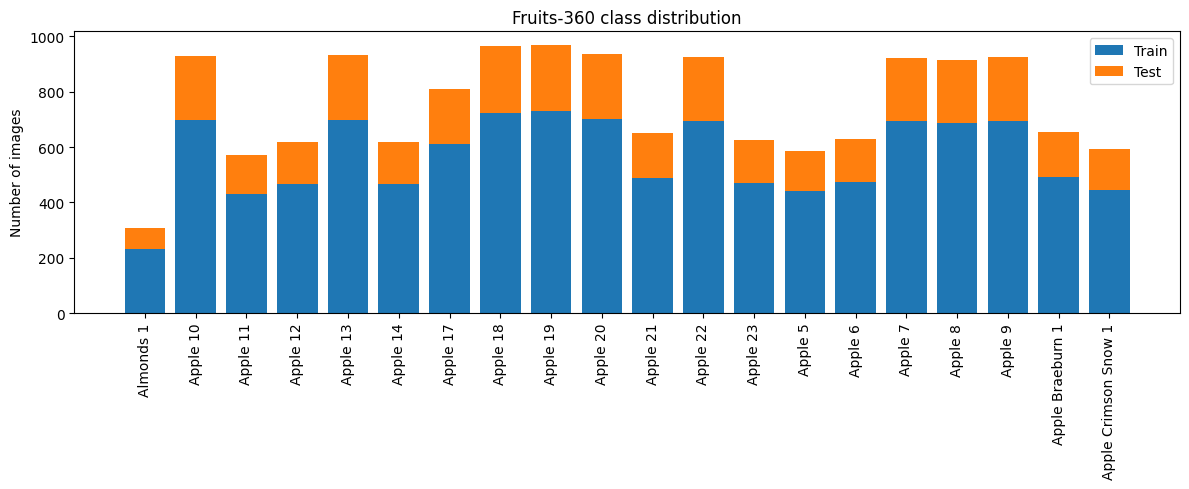

In [5]:



def count_images_by_class(directory: Path, classes: list[str]) -> pd.DataFrame:
    rows = []
    for cls in classes:
        cls_dir = directory / cls
        n = count_image_files(cls_dir)
        rows.append({'class': cls, 'n_images': n})
    return pd.DataFrame(rows)


train_counts = count_images_by_class(TRAIN_DIR, selected_classes)
test_counts = count_images_by_class(TEST_DIR, selected_classes)
eda_table = train_counts.merge(test_counts, on='class', suffixes=('_train', '_test'))
eda_table['total'] = eda_table['n_images_train'] + eda_table['n_images_test']
eda_table['train_ratio'] = eda_table['n_images_train'] / eda_table['total']
eda_table.to_csv(REPORT_DIR / 'eda_class_distribution.csv', index=False)

print('\nEDA - class distribution:')
print(eda_table)

plt.figure(figsize=(12, 5))
plt.bar(eda_table['class'], eda_table['n_images_train'], label='Train')
plt.bar(
    eda_table['class'],
    eda_table['n_images_test'],
    bottom=eda_table['n_images_train'],
    label='Test',
)
plt.xticks(rotation=90)
plt.ylabel('Number of images')
plt.title('Fruits-360 class distribution')
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'class_distribution.png', dpi=200)
plt.show()

In [6]:


train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=selected_classes,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=selected_classes,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=selected_classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE

Found 11335 files belonging to 20 classes.
Using 9068 files for training.


I0000 00:00:1777940675.515245      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777940675.521376      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 11335 files belonging to 20 classes.
Using 2267 files for validation.
Found 3761 files belonging to 20 classes.


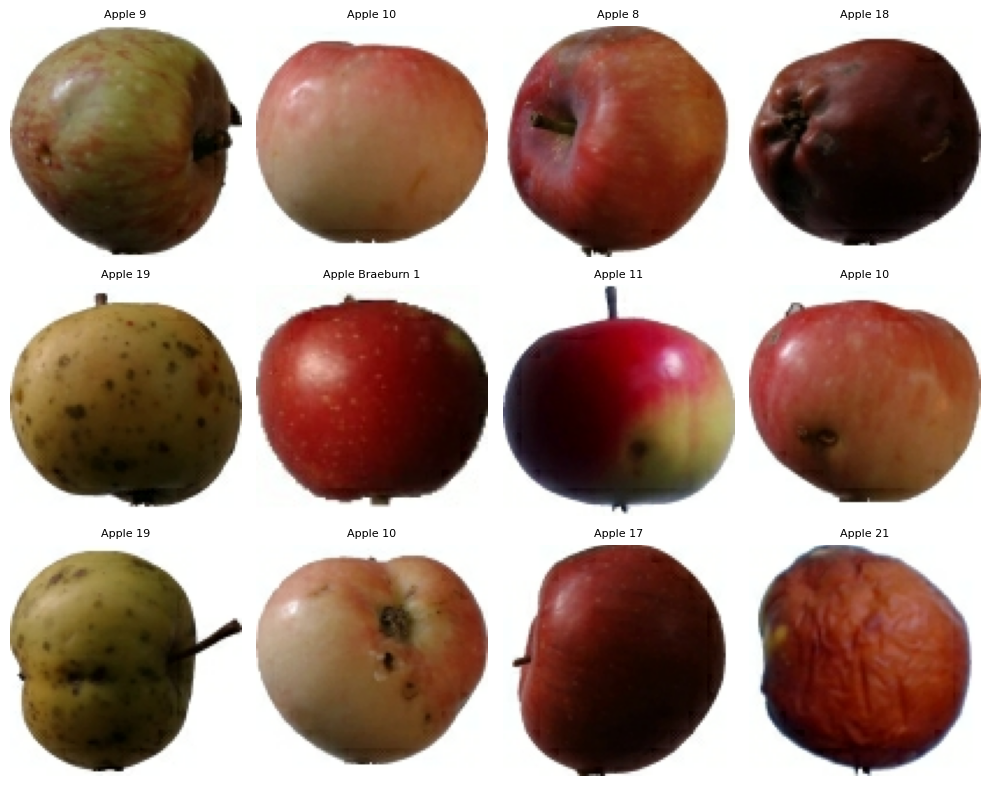

In [7]:


train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# Ve anh mau cho bao cao.
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    n_show = min(12, images.shape[0])
    for i in range(n_show):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(np.argmax(labels[i].numpy()))], fontsize=8)
        plt.axis('off')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'sample_images.png', dpi=200)
plt.show()

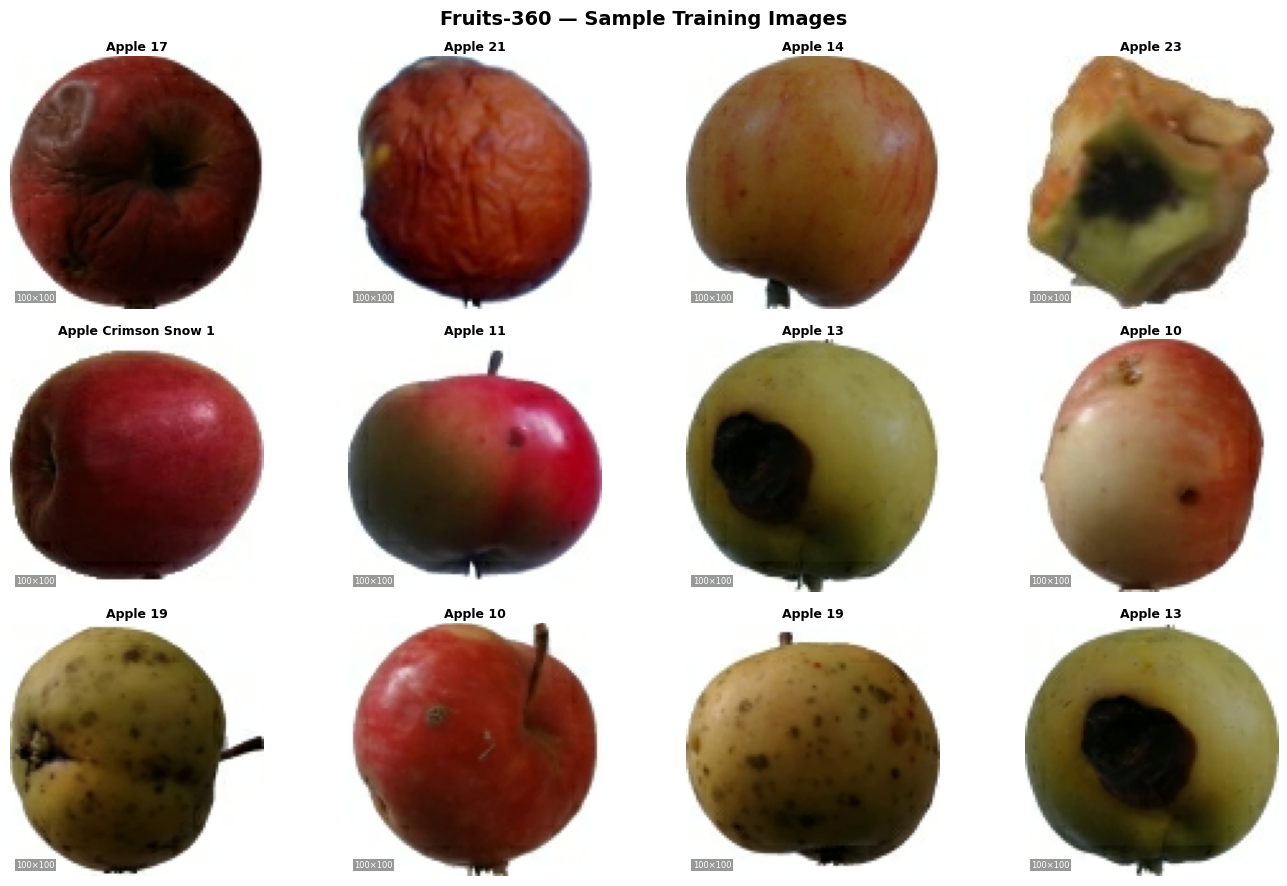

In [8]:
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# ── Sample images visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle('Fruits-360 — Sample Training Images', fontsize=14, fontweight='bold')

for images, labels in train_ds.take(1):
    n_show = min(12, images.shape[0])
    for i in range(n_show):
        ax = axes[i // 4, i % 4]
        img   = images[i].numpy().astype('uint8')
        label = class_names[int(np.argmax(labels[i].numpy()))]

        ax.imshow(img)
        ax.set_title(label, fontsize=9, fontweight='bold', pad=4)
        ax.axis('off')

        # colored border per image
        for spine in ax.spines.values():
            spine.set_edgecolor('#4C72B0')
            spine.set_linewidth(2.5)
            spine.set_visible(True)

        # image size label bottom-left
        ax.text(2, img.shape[0] - 4, f'{img.shape[1]}×{img.shape[0]}',
                fontsize=6, color='white',
                bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

plt.tight_layout()
plt.savefig(PLOT_DIR / 'sample_images.png', dpi=200, bbox_inches='tight')
plt.show()

In [10]:


def compile_model(model: keras.Model, learning_rate: float = 1e-3) -> keras.Model:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


callbacks_common = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6
    ),
]

In [11]:


def plot_history(history: keras.callbacks.History, model_name: str) -> None:
    hist = pd.DataFrame(history.history)
    hist.to_csv(REPORT_DIR / f'history_{model_name}.csv', index=False)

    plt.figure(figsize=(7, 5))
    plt.plot(hist['accuracy'], label='train_accuracy')
    plt.plot(hist['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy - {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'accuracy_{model_name}.png', dpi=200)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(hist['loss'], label='train_loss')
    plt.plot(hist['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Loss - {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'loss_{model_name}.png', dpi=200)
    plt.show()

In [12]:



def get_predictions(model: keras.Model, dataset: tf.data.Dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)


In [13]:



def evaluate_and_save(model: keras.Model, model_name: str) -> dict:
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    y_true, y_pred = get_predictions(model, test_ds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    report_text = classification_report(
        y_true, y_pred, target_names=class_names, zero_division=0
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )

    with open(REPORT_DIR / f'classification_report_{model_name}.txt', 'w', encoding='utf-8') as f:
        f.write(report_text)
    pd.DataFrame(report_dict).transpose().to_csv(
        REPORT_DIR / f'classification_report_{model_name}.csv'
    )

    cm = confusion_matrix(y_true, y_pred)
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        REPORT_DIR / f'confusion_matrix_{model_name}.csv'
    )

    plt.figure(figsize=(12, 10))
    plt.imshow(cm)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.xticks(range(NUM_CLASSES), class_names, rotation=90, fontsize=7)
    plt.yticks(range(NUM_CLASSES), class_names, fontsize=7)
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'confusion_matrix_{model_name}.png', dpi=200)
    plt.show()

    model.save(MODEL_DIR / f'{model_name}.keras')

    return {
        'model': model_name,
        'test_loss': float(test_loss),
        'accuracy': float(test_acc),
        'precision_weighted': float(precision),
        'recall_weighted': float(recall),
        'f1_weighted': float(f1),
    }


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,292 (118.33 KB)

 Trainable params: 30,292 (118.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6


I0000 00:00:1777941065.860094     152 service.cc:152] XLA service 0x7dff0004b9b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777941065.860137     152 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777941065.860143     152 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777941066.291866     152 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/284 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0469 - loss: 2.9937

I0000 00:00:1777941069.493624     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


284/284 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.1429 - loss: 2.6941 - val_accuracy: 0.5443 - val_loss: 1.3026 - learning_rate: 0.0010
Epoch 2/6
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5212 - loss: 1.3012 - val_accuracy: 0.7022 - val_loss: 0.8323 - learning_rate: 0.0010
Epoch 3/6
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6413 - loss: 0.9457 - val_accuracy: 0.7428 - val_loss: 0.6723 - learning_rate: 0.0010
Epoch 4/6
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7006 - loss: 0.7803 - val_accuracy: 0.8006 - val_loss: 0.5492 - learning_rate: 0.0010
Epoch 5/6
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7514 - loss: 0.6401 - val_accuracy: 0.8491 - val_loss: 0.4439 - learning_rate: 0.0010
Epoch 6/6
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8025 - loss: 0.5242 - val_accuracy: 0.8946 - val_loss: 0.3372 - learning_rate: 0.0010


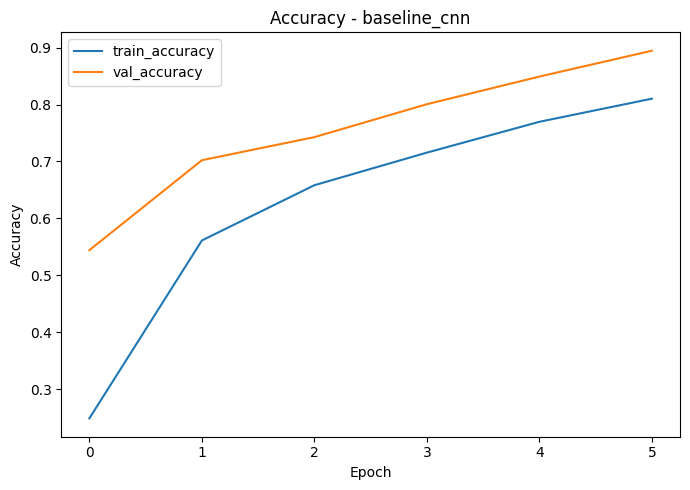

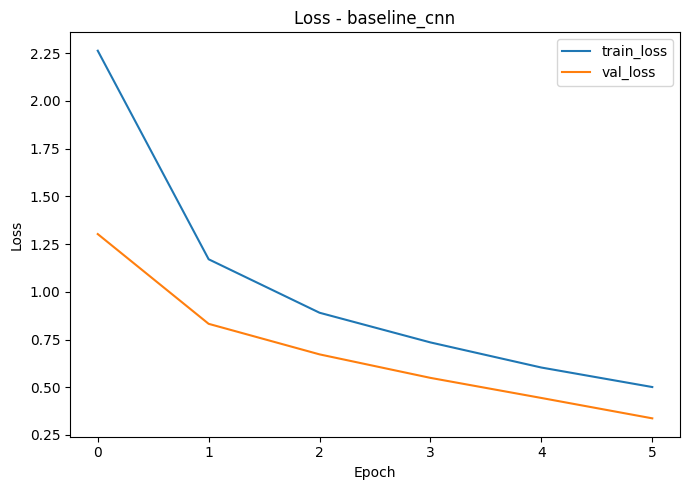

In [14]:

def build_baseline_cnn() -> keras.Model:
    model = keras.Sequential(
        [
            layers.Input(shape=IMG_SIZE + (3,)),
            layers.Rescaling(1.0 / 255),
            layers.Conv2D(32, 3, activation='relu', padding='same'),
            layers.MaxPooling2D(),
            layers.Conv2D(64, 3, activation='relu', padding='same'),
            layers.MaxPooling2D(),
            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.30),
            layers.Dense(NUM_CLASSES, activation='softmax'),
        ],
        name='Baseline_CNN',
    )
    return compile_model(model, learning_rate=1e-3)


baseline_cnn = build_baseline_cnn()
baseline_cnn.summary()
history_baseline = baseline_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    callbacks=callbacks_common,
)
plot_history(history_baseline, 'baseline_cnn')


Model: "Custom_CNN_Augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             

 Total params: 326,964 (1.25 MB)

 Trainable params: 326,068 (1.24 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/8


E0000 00:00:1777941111.553340      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Custom_CNN_Augmentation_1/dropout_1_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


284/284 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - accuracy: 0.6462 - loss: 1.1298 - val_accuracy: 0.1292 - val_loss: 8.4924 - learning_rate: 0.0010
Epoch 2/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - accuracy: 0.9187 - loss: 0.2343 - val_accuracy: 0.7671 - val_loss: 0.7279 - learning_rate: 0.0010
Epoch 3/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.9464 - loss: 0.1554 - val_accuracy: 0.8875 - val_loss: 0.3634 - learning_rate: 0.0010
Epoch 4/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9718 - loss: 0.0939 - val_accuracy: 0.9929 - val_loss: 0.0282 - learning_rate: 0.0010
Epoch 5/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9703 - loss: 0.0793 - val_accuracy: 0.9634 - val_loss: 0.1231 - learning_rate: 0.0010
Epoch 6/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9797 - loss: 0.0635 - val_accuracy: 0.9250 - val_loss: 0.2141 - learning_rate: 0.0010
Epoch 7/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9916 - loss: 0.0259 - val

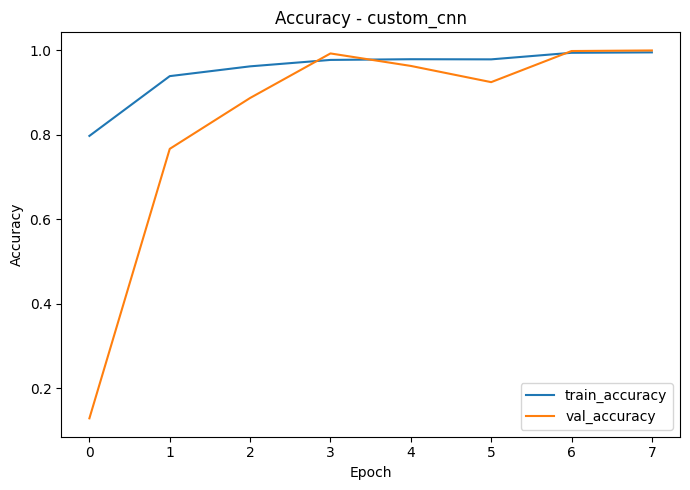

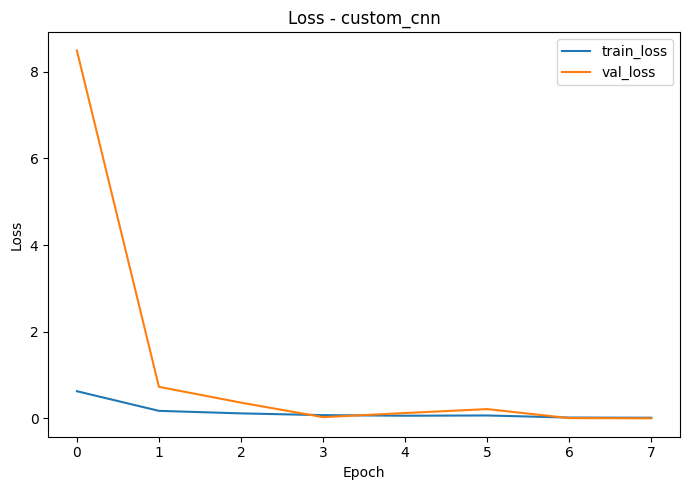

In [15]:


def build_custom_cnn() -> keras.Model:
    data_augmentation = keras.Sequential(
        [
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.08),
            layers.RandomZoom(0.10),
            layers.RandomContrast(0.10),
        ],
        name='data_augmentation',
    )

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.20)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='Custom_CNN_Augmentation')
    return compile_model(model, learning_rate=1e-3)


custom_cnn = build_custom_cnn()
custom_cnn.summary()
history_custom = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CUSTOM_CNN,
    callbacks=callbacks_common,
)
plot_history(history_custom, 'custom_cnn')

/tmp/ipykernel_57/1928795276.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded with ImageNet pretrained weights.


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 100, 100, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │        25,620 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,283,604 (8.71 MB)

 Trainable params: 25,620 (100.08 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.5577 - loss: 1.6282 - val_accuracy: 0.9740 - val_loss: 0.1186 - learning_rate: 0.0010
Epoch 2/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9329 - loss: 0.2057 - val_accuracy: 0.9854 - val_loss: 0.0663 - learning_rate: 0.0010
Epoch 3/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9614 - loss: 0.1131 - val_accuracy: 0.9899 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 4/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9725 - loss: 0.0805 - val_accuracy: 0.9982 - val_loss: 0.0261 - learning_rate: 0.0010
Epoch 5/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9795 - loss: 0.0609 - val_accuracy: 0.9969 - val_loss: 0.0266 - learning_rate: 0.0010
Epoch 6/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9836 - loss: 0.0546 - val_accuracy: 0.9987 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 7/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9900 - loss: 0.0372 -

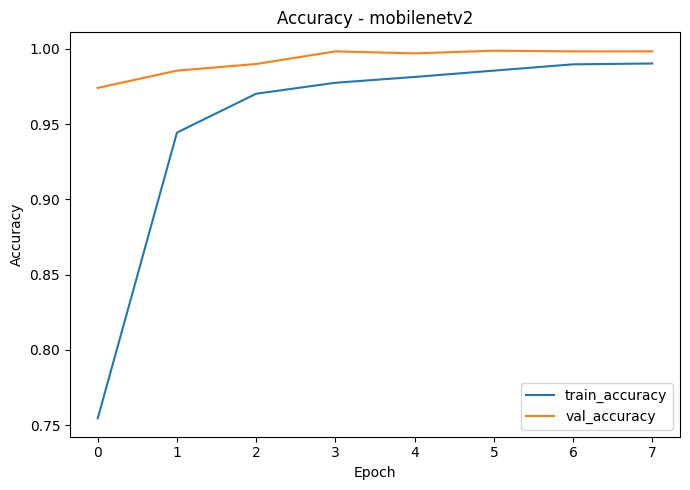

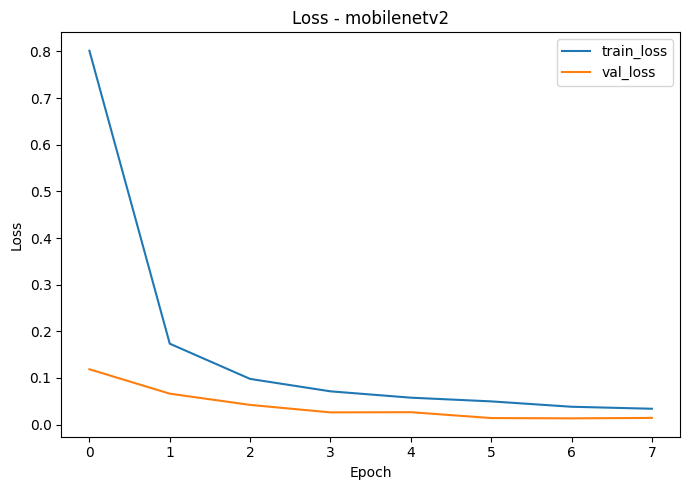

In [18]:
def build_mobilenetv2() -> keras.Model:
    try:                          # ← 4 spaces
        base_model = keras.applications.MobileNetV2(
            input_shape=IMG_SIZE + (3,),
            include_top=False,
            weights='imagenet',
        )
        print('MobileNetV2 loaded with ImageNet pretrained weights.')
    except Exception as e:
        print('Cannot load ImageNet weights. Falling back to weights=None. Reason:', repr(e))
        base_model = keras.applications.MobileNetV2(
            input_shape=IMG_SIZE + (3,),
            include_top=False,
            weights=None,
        )

    base_model.trainable = False
    preprocess = keras.applications.mobilenet_v2.preprocess_input

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomRotation(0.05)(x)
    x = preprocess(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2')
    return compile_model(model, learning_rate=1e-3)


mobilenetv2 = build_mobilenetv2()
mobilenetv2.summary()

history_mobilenet = mobilenetv2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_MOBILENET,
    callbacks=callbacks_common,
)
plot_history(history_mobilenet, 'mobilenetv2')

Epoch 1/3
284/284 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.6481 - loss: 1.2705 - val_accuracy: 0.9916 - val_loss: 0.0241 - learning_rate: 1.0000e-05
Epoch 2/3
284/284 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9150 - loss: 0.3164 - val_accuracy: 0.9934 - val_loss: 0.0236 - learning_rate: 1.0000e-05
Epoch 3/3
284/284 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9605 - loss: 0.1562 - val_accuracy: 0.9956 - val_loss: 0.0189 - learning_rate: 1.0000e-05


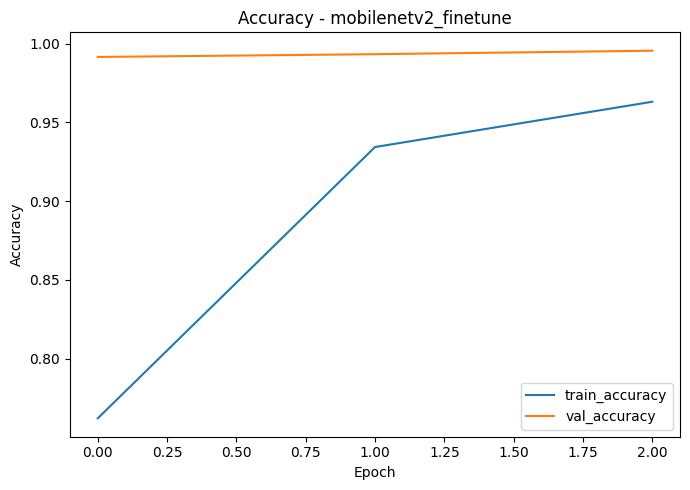

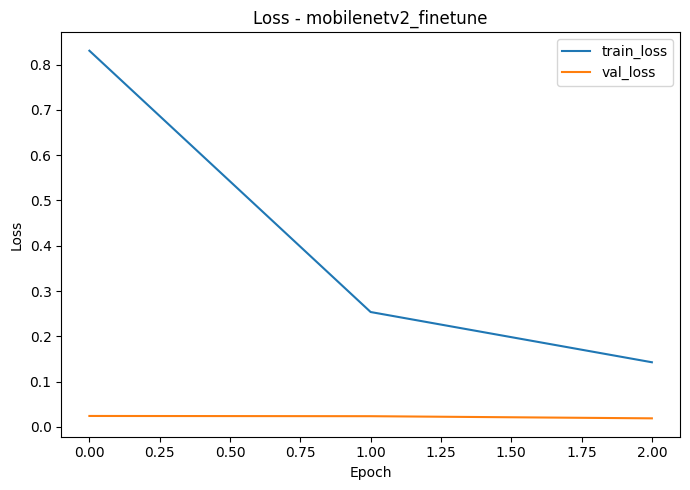

In [19]:


try:
    base_model = None
    for layer in mobilenetv2.layers:
        if isinstance(layer, keras.Model) and 'mobilenetv2' in layer.name.lower():
            base_model = layer
            break

    if base_model is not None:
        base_model.trainable = True
        for layer in base_model.layers[:-20]:
            layer.trainable = False

        mobilenetv2 = compile_model(mobilenetv2, learning_rate=1e-5)
        history_mobilenet_ft = mobilenetv2.fit(
            train_ds,
            validation_data=val_ds,
            epochs=3,
            callbacks=callbacks_common,
        )
        plot_history(history_mobilenet_ft, 'mobilenetv2_finetune')
except Exception as e:
    print('MobileNetV2 fine-tuning skipped:', repr(e))

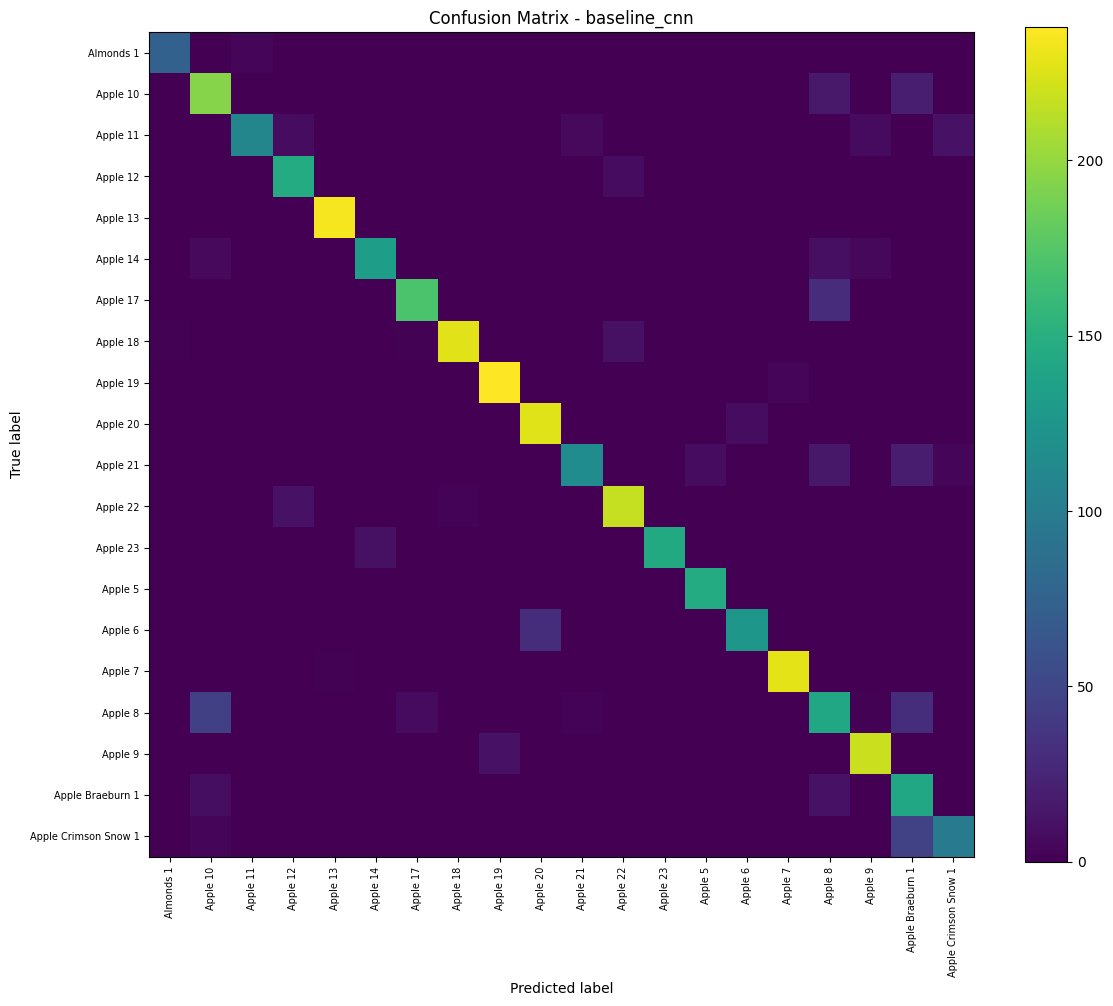

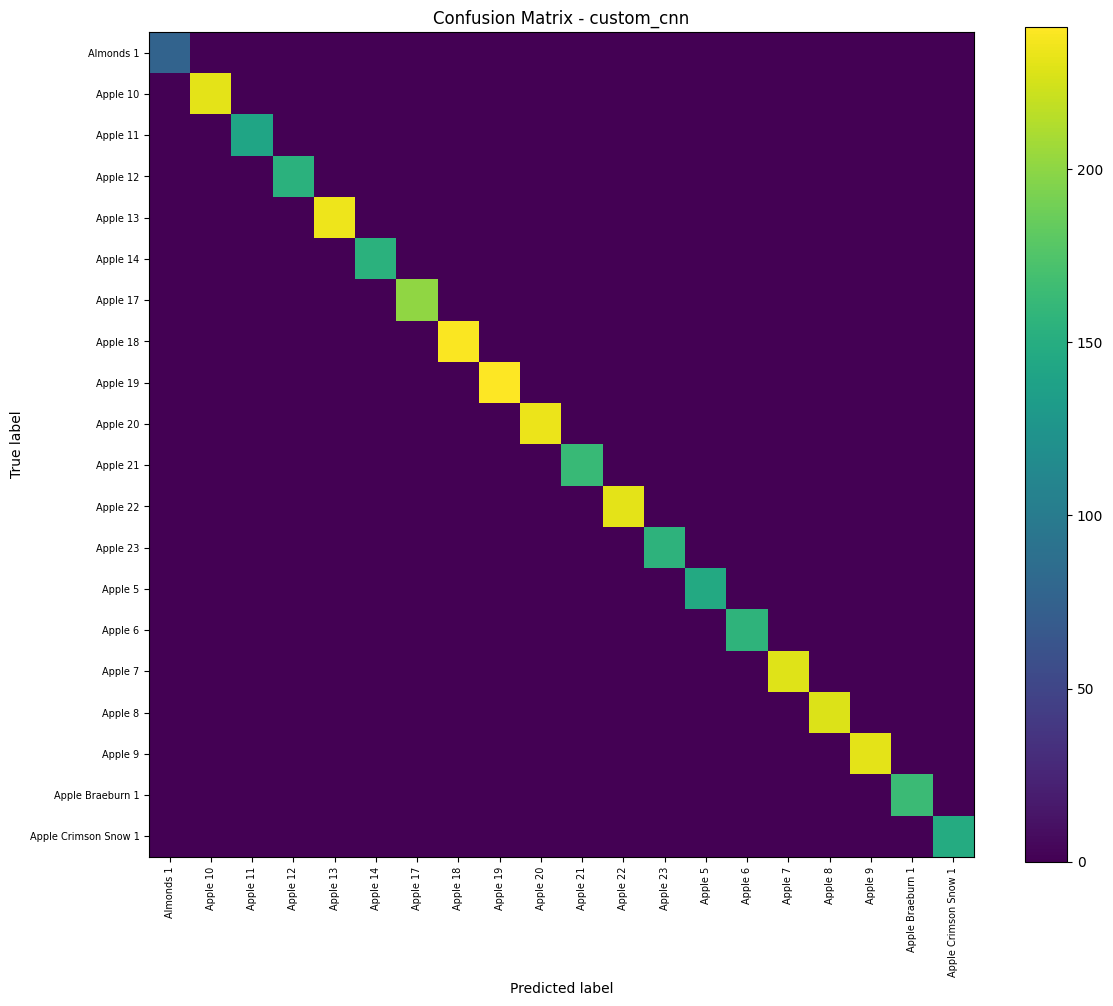

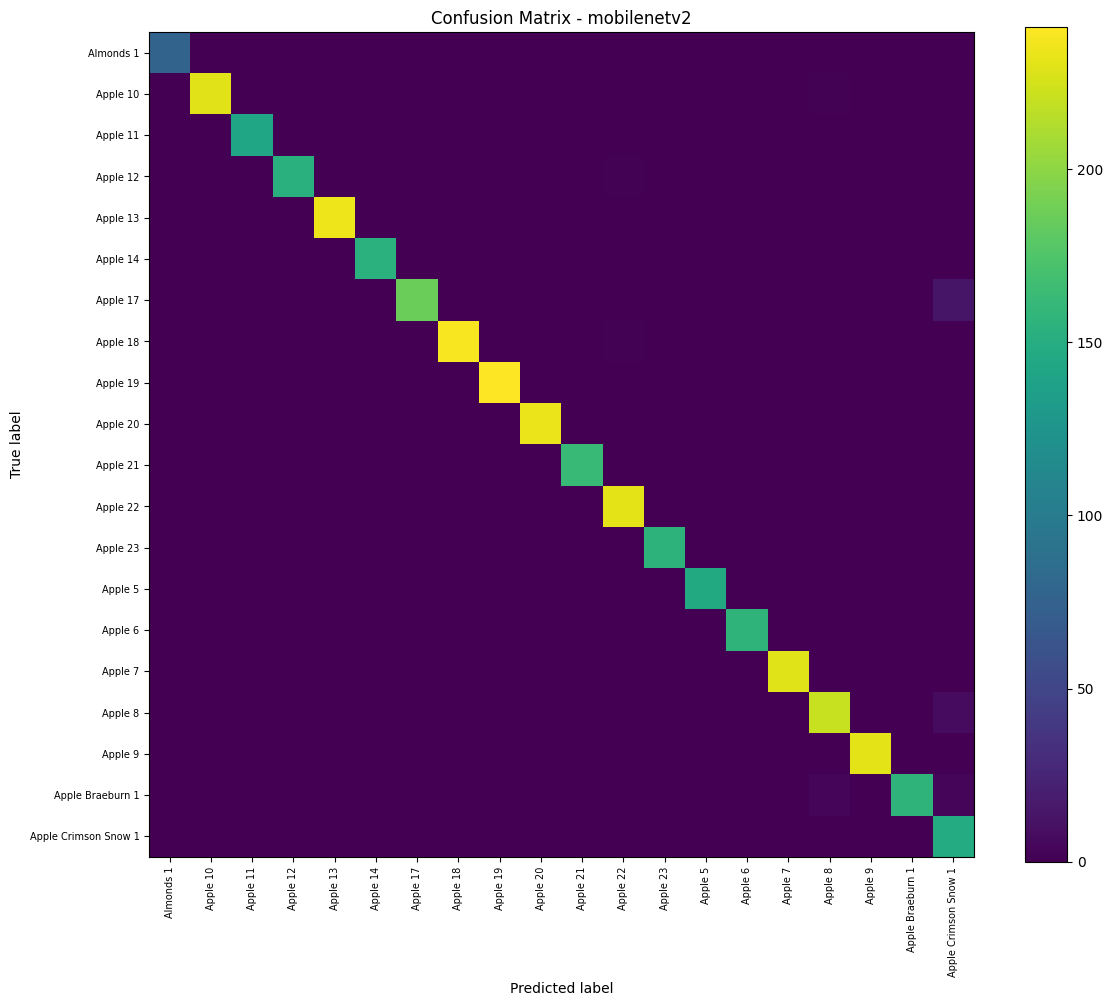


MODEL COMPARISON RESULTS
          model  test_loss  accuracy  precision_weighted  recall_weighted  \
1    custom_cnn   0.000981  1.000000            1.000000         1.000000   
2   mobilenetv2   0.024944  0.991758            0.992708         0.991758   
0  baseline_cnn   0.345446  0.886732            0.898033         0.886732   

   f1_weighted  
1     1.000000  
2     0.991919  
0     0.888349  


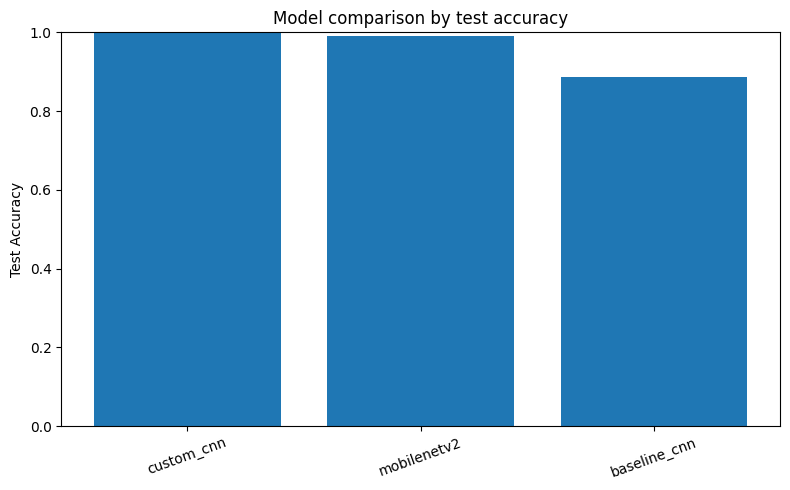

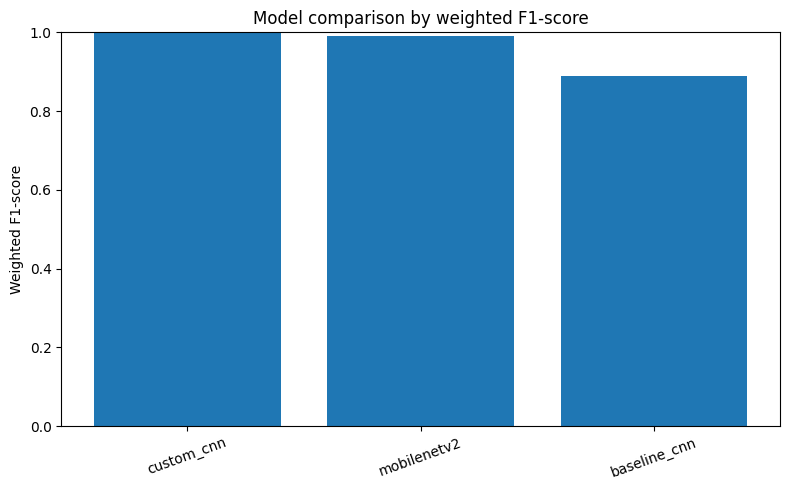

In [20]:

results = []
results.append(evaluate_and_save(baseline_cnn, 'baseline_cnn'))
results.append(evaluate_and_save(custom_cnn, 'custom_cnn'))
results.append(evaluate_and_save(mobilenetv2, 'mobilenetv2'))

results_df = pd.DataFrame(results).sort_values(by='f1_weighted', ascending=False)
results_df.to_csv(REPORT_DIR / 'model_comparison_results.csv', index=False)

print('\nMODEL COMPARISON RESULTS')
print(results_df)

plt.figure(figsize=(8, 5))
plt.bar(results_df['model'], results_df['accuracy'])
plt.ylim(0, 1)
plt.ylabel('Test Accuracy')
plt.title('Model comparison by test accuracy')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_comparison_accuracy.png', dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(results_df['model'], results_df['f1_weighted'])
plt.ylim(0, 1)
plt.ylabel('Weighted F1-score')
plt.title('Model comparison by weighted F1-score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_comparison_f1.png', dpi=200)
plt.show()

In [22]:


best_model_name = str(results_df.iloc[0]['model'])
experiment_summary = {
    'dataset_kaggle_url': 'https://www.kaggle.com/datasets/moltean/fruits',
    'dataset_root_detected': str(DATA_ROOT),
    'num_original_classes': len(all_classes),
    'num_selected_classes': NUM_CLASSES,
    'selected_classes': selected_classes,
    'best_model_by_weighted_f1': best_model_name,
    'results': results_df.to_dict(orient='records'),
}

with open(REPORT_DIR / 'experiment_summary.json', 'w', encoding='utf-8') as f:
    json.dump(experiment_summary, f, ensure_ascii=False, indent=2)
